# Phase 2b — Exploration des personnages joueurs

Source : dépôt `oganm/dnddata` — fiches de personnages D&D 5e réelles, dédupliquées.

Mêmes étapes que pour les monstres :
1. Premier aperçu (structure, types)
2. Qualité des données (valeurs manquantes, doublons)
3. Distributions des colonnes clés
4. Corrélations entre features

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

RAW = Path.cwd().parent / "data" / "raw"
RESULTS = Path.cwd().parent / "results"
RESULTS.mkdir(exist_ok=True)

## 1. Chargement et premier aperçu

In [2]:
chars = pd.read_csv(RAW / "characters_unique.csv")
print("Shape :", chars.shape)
chars.head()

Shape : (7946, 35)


,ip,finger,hash,name,race,background,date,class,justClass,subclass,level,feats,HP,AC,Str,Dex,Con,Int,Wis,Cha,alignment,skills,weapons,spells,castingStat,choices,country,countryCode,processedAlignment,good,lawful,processedRace,processedSpells,processedWeapons,alias
0,NaN,NaN,cae5e618234ee137e3c63d733786562d,076d33f5,Kenku,Guild Member - Spycraft,2022-08-21T21:36:28Z,Ranger 20,Ranger,Beast Master,20,NaN,94,16,13,16,13,15,15,14,NaN,Acrobatics|Stealth|Investigation|Insight|Perce...,Dagger|Dagger|Longbow,Fog Cloud*1|Absorb Elements*1|Speak With Anima...,Wis,expertise/Perception|fighting style/Archery|op...,Canada,CA,NaN,NaN,NaN,Kenku,Fog Cloud*1|Absorb Elements*1|Speak with Anima...,Dagger|Dagger|Longbow,compassionate_mclaren
1,NaN,168df55,e60ba474b72646161a0eda0111f43a4e,1747c66f,Fallen Aasimar,Far Traveler,2022-08-21T21:13:26Z,Druid 20,Druid,Circle of the Moon,20,Telekinetic|Elemental Adept|Savage Attacker,116,13,14,15,12,11,17,11,Chaotic neutral,Arcana|Nature|Insight|Perception,Quarterstaff|Dagger,Infestation*0|Light*0|Poison Spray*0|Primal Sa...,Wis,NaN,Canada,CA,CN,NaN,NaN,Aasimar,Infestation*0|Light*0|Poison Spray*0|Primal Sa...,Quarterstaff|Dagger,crazy_gould
2,NaN,2883dc0,5307fd9971cdc6c718382ab2c28eee79,e38541dc,Leonin,Soldier,2022-08-17T11:20:11Z,Fighter 20,Fighter,Rune Knight,20,Durable|Mage Slayer|Tough|Great Weapon Master|...,290,18,25,19,20,18,15,13,Lawful Good Boi,Athletics|Acrobatics|Survival|Intimidation,Flame Tongue|Flame Tongue (GWM),NaN,Int,fighting style/Great Weapon Fighting,Canada,CA,LG,NaN,NaN,Leonin,NaN,|,brave_rhodes
3,fe2ccee,d00f08e,6eacdd847b0a192ed5274d215e6a2bed,8f563448,Warforged,Barbarian Tribe Member,2022-08-13T20:04:58Z,Druid 20,Druid,Circle of the Moon,20,NaN,183,15,18,12,18,10,18,9,NaN,Athletics|Nature|Animal Handling|Medicine|Surv...,Scimitar,NaN,Wis,NaN,United States,US,NaN,NaN,NaN,Warforged,NaN,Scimitar,flamboyant_chandrasekhar
4,6fdd75d,461d953,bcb6122fe0174ce0dd17c9a9afeae303,be717d80,Tiefling,Acolyte,2022-06-28T18:42:34Z,Cleric 20,Cleric,Tempest Domain,20,War Caster|Mobile,183,18,10,14,18,14,20,8,NaN,Religion|Insight|Medicine|Persuasion,Mace,Sacred Flame*0|Spare The Dying*0|Fog Cloud*1|T...,Wis,NaN,NaN,NaN,NaN,NaN,NaN,Tiefling,Sacred Flame*0|Spare the Dying*0|Fog Cloud*1|T...,Mace,dreamy_banzai


In [3]:
chars.dtypes

ip                        str
finger                    str
hash                      str
name                      str
race                      str
background                str
date                      str
class                     str
justClass                 str
subclass                  str
level                   int64
feats                     str
HP                      int64
AC                      int64
Str                     int64
Dex                     int64
Con                     int64
Int                     int64
Wis                     int64
Cha                     int64
alignment                 str
skills                    str
weapons                   str
spells                    str
castingStat               str
choices                   str
country                   str
countryCode               str
processedAlignment        str
good                  float64
lawful                float64
processedRace             str
processedSpells           str
processedW

In [4]:
chars.describe()

,level,HP,AC,Str,Dex,Con,Int,Wis,Cha,good,lawful
count,7946.000000,7946.000000,7946.000000,7946.000000,7946.000000,7946.000000,7946.000000,7946.000000,7946.000000,0.0,0.0
mean,4.780770,43.616411,15.228039,12.801158,14.592499,14.333375,12.005537,13.118550,13.091996,NaN,NaN
std,4.082567,60.393802,3.483392,4.018426,3.152002,2.585769,3.206463,3.173568,3.676807,NaN,NaN
min,1.000000,-6.000000,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,1.000000,14.000000,13.000000,10.000000,13.000000,13.000000,10.000000,11.000000,10.000000,NaN,NaN
50%,4.000000,31.000000,15.000000,12.000000,15.000000,14.000000,12.000000,13.000000,13.000000,NaN,NaN
75%,6.000000,54.000000,17.000000,16.000000,16.000000,16.000000,14.000000,15.000000,16.000000,NaN,NaN
max,20.000000,3764.000000,222.000000,103.000000,101.000000,103.000000,99.000000,100.000000,99.000000,NaN,NaN


## 2. Qualité des données

### 2a. Valeurs manquantes

In [5]:
missing = (
    chars.isnull()
    .sum()
    .rename("n_missing")
    .to_frame()
    .assign(pct=lambda d: (d["n_missing"] / len(chars) * 100).round(1))
)
missing[missing["n_missing"] > 0].sort_values("n_missing", ascending=False)

,n_missing,pct
lawful,7946,100.0
good,7946,100.0
processedAlignment,5922,74.5
alignment,5872,73.9
feats,5354,67.4
spells,4522,56.9
processedSpells,4522,56.9
choices,3710,46.7
country,2340,29.4
countryCode,2340,29.4


### 2b. Doublons

In [6]:
print("Lignes entièrement dupliquées :", chars.duplicated().sum())
print("Hashs dupliqués               :", chars["hash"].duplicated().sum())

# Valeurs aberrantes évidentes dans les colonnes numériques clés
print("\nValeurs hors bornes (HP <= 0 ou HP > 1000) :",
      chars[(chars["HP"] <= 0) | (chars["HP"] > 1000)].shape[0])
print("Valeurs hors bornes (AC <= 0 ou AC > 40)  :",
      chars[(chars["AC"] <= 0) | (chars["AC"] > 40)].shape[0])
print("Niveaux hors bornes (< 1 ou > 20)         :",
      chars[(chars["level"] < 1) | (chars["level"] > 20)].shape[0])

Lignes entièrement dupliquées : 0
Hashs dupliqués               : 0

Valeurs hors bornes (HP <= 0 ou HP > 1000) : 10
Valeurs hors bornes (AC <= 0 ou AC > 40)  : 2
Niveaux hors bornes (< 1 ou > 20)         : 0


## 3. Distributions des colonnes clés

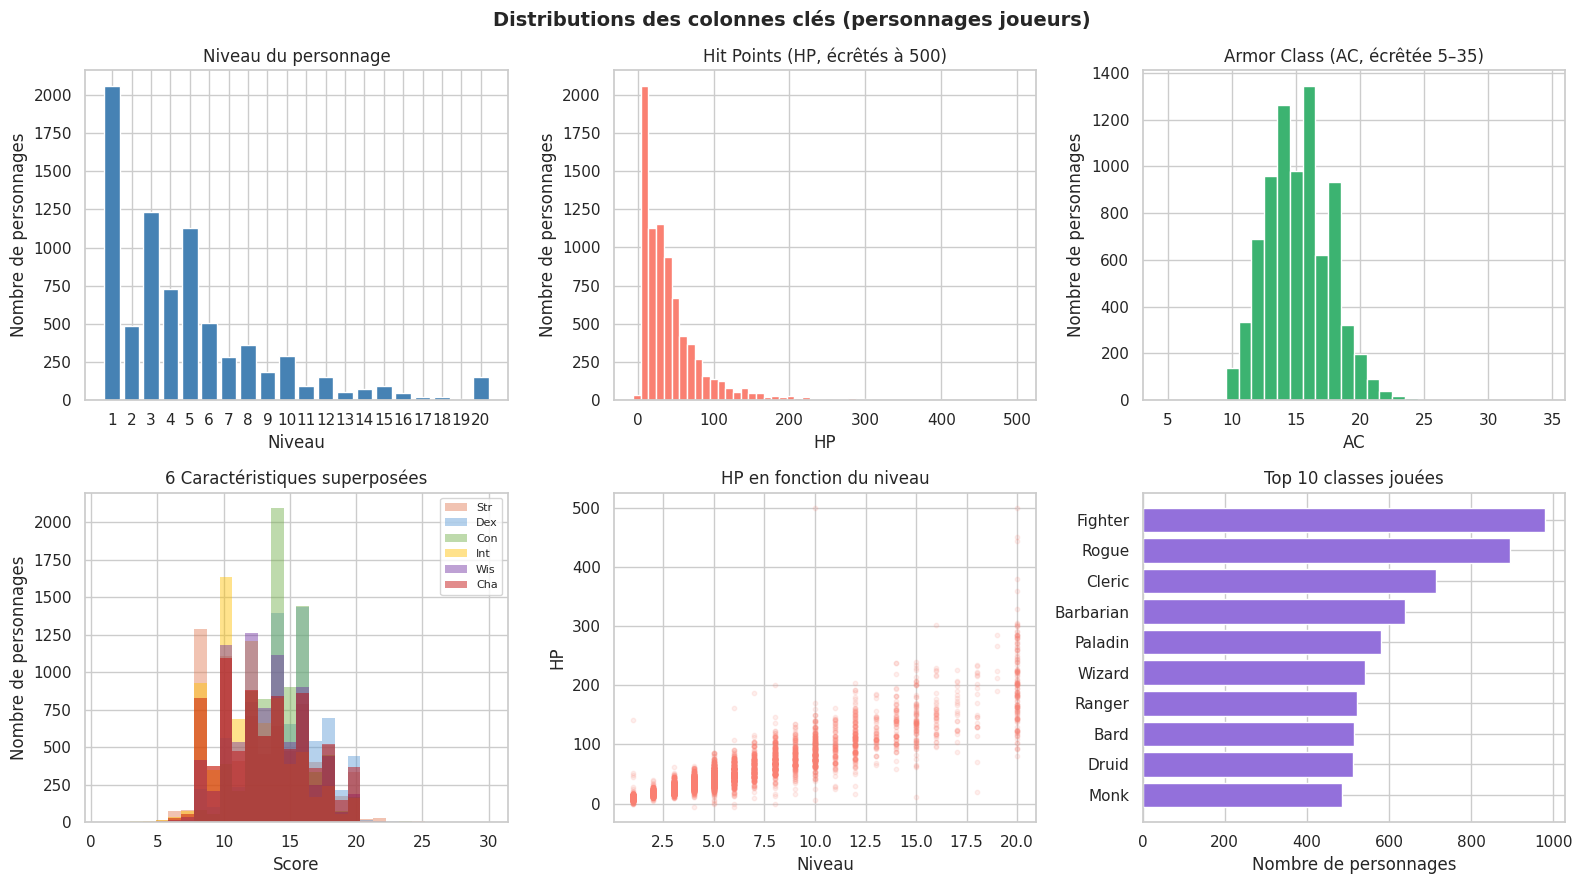

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distributions des colonnes clés (personnages joueurs)", fontsize=14, fontweight="bold")

# Niveau
level_counts = chars["level"].value_counts().sort_index()
axes[0, 0].bar(level_counts.index, level_counts.values, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Niveau du personnage")
axes[0, 0].set_xlabel("Niveau")
axes[0, 0].set_ylabel("Nombre de personnages")
axes[0, 0].set_xticks(range(1, 21))

# HP
hp_clean = chars["HP"].clip(upper=500)
axes[0, 1].hist(hp_clean, bins=50, color="salmon", edgecolor="white")
axes[0, 1].set_title("Hit Points (HP, écrêtés à 500)")
axes[0, 1].set_xlabel("HP")
axes[0, 1].set_ylabel("Nombre de personnages")

# AC
ac_clean = chars["AC"].clip(lower=5, upper=35)
axes[0, 2].hist(ac_clean, bins=range(5, 36), color="mediumseagreen", edgecolor="white", align="left")
axes[0, 2].set_title("Armor Class (AC, écrêtée 5–35)")
axes[0, 2].set_xlabel("AC")
axes[0, 2].set_ylabel("Nombre de personnages")

# 6 stats
stat_cols = ["Str", "Dex", "Con", "Int", "Wis", "Cha"]
colors = ["#e07b54", "#5b9bd5", "#70ad47", "#ffc000", "#7030a0", "#c00000"]
for col, color in zip(stat_cols, colors):
    axes[1, 0].hist(chars[col].dropna().clip(1, 30), bins=30, alpha=0.45,
                    label=col, color=color, edgecolor="none")
axes[1, 0].set_title("6 Caractéristiques superposées")
axes[1, 0].set_xlabel("Score")
axes[1, 0].set_ylabel("Nombre de personnages")
axes[1, 0].legend(fontsize=8)

# HP vs niveau
axes[1, 1].scatter(chars["level"], chars["HP"].clip(upper=500),
                   alpha=0.12, s=10, color="salmon")
axes[1, 1].set_title("HP en fonction du niveau")
axes[1, 1].set_xlabel("Niveau")
axes[1, 1].set_ylabel("HP")

# Top 10 classes
top_classes = chars["justClass"].value_counts().head(10)
axes[1, 2].barh(top_classes.index[::-1], top_classes.values[::-1],
                color="mediumpurple", edgecolor="white")
axes[1, 2].set_title("Top 10 classes jouées")
axes[1, 2].set_xlabel("Nombre de personnages")

plt.tight_layout()
plt.savefig(RESULTS / "characters_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### Lecture des graphiques

**Niveau (haut gauche)** — Distribution bimodale avec deux pics marqués : niveau 1 (2060 personnages — beaucoup de fiches abandonnées en début de campagne) et niveau 20 (149 — personnages maximaux souvent créés pour tester des builds). Les niveaux 3–5 sont bien représentés, puis ça chute régulièrement.
> **Implication ML** : le niveau 1 va surreprésenter les combats très faciles dans notre jeu d'entraînement. Il faudra stratifier par niveau.

**HP (haut centre)** — Asymétrique à droite comme pour les monstres, mais moins extrême. La majorité des personnages ont entre 10 et 150 HP, ce qui correspond aux niveaux 1–10. Quelques valeurs extrêmes écrêtées à 500.

**AC (haut droite)** — Centrée autour de 14–16, légèrement asymétrique vers les hautes valeurs (paladin/barbare optimisés). Comparable aux monstres en termes de plage.

**6 caractéristiques (bas gauche)** — Toutes concentrées autour de 10–18, plus resserrées que pour les monstres. Les joueurs optimisent leurs stats primaires → peu de valeurs < 8 dans les stats importantes. La distribution est moins étalée que chez les monstres.

**HP vs niveau (bas centre)** — Corrélation visible mais avec énorme variance à chaque niveau. À niveau 20, les HP vont de ~100 à ~500+ selon la classe et CON. Ça confirme que le niveau seul ne suffit pas à caractériser un personnage.

**Top 10 classes (bas droite)** — Fighter et Rogue dominent (~1000 personnages chacun). Les classes martiales (Fighter, Barbarian, Paladin) sont plus représentées que les lanceurs de sorts purs. Cela reflète les préférences réelles des joueurs.
> **Implication ML** : les profils de combat varient beaucoup selon la classe (un Barbarian et un Wizard au même niveau ont des HP, AC et rôles très différents). La classe sera une feature catégorielle importante en Phase 3.

## 4. Corrélations entre features

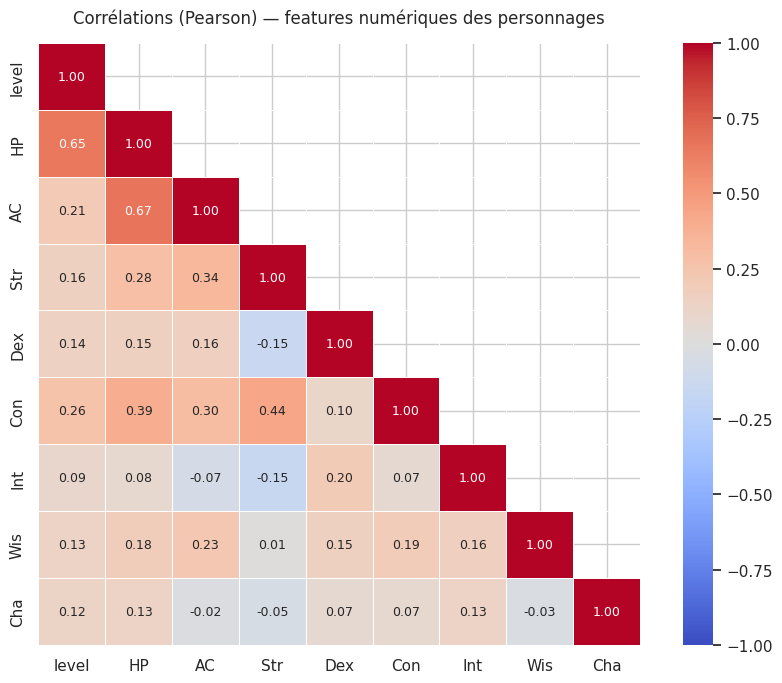

In [8]:
FEATURES = ["level", "HP", "AC", "Str", "Dex", "Con", "Int", "Wis", "Cha"]
corr = chars[FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
)
ax.set_title("Corrélations (Pearson) — features numériques des personnages", fontsize=12, pad=14)
plt.tight_layout()
plt.savefig(RESULTS / "characters_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

### Lecture de la heatmap

**Contraste avec les monstres** : les corrélations sont globalement **beaucoup plus faibles**. Les joueurs font des choix libres (race, classe, feat, équipement) qui cassent les corrélations naturelles qu'on trouvait chez les monstres. Un Wizard peut avoir une Constitution faible et une Intelligence élevée — il n'y a pas de "design cohérent" imposé.

**Corrélations avec le niveau** (première colonne — notre proxy de puissance du groupe) :

| Feature | Corrélation avec level | Interprétation |
|---|---|---|
| `HP` | **0.65** | Forte — HP monte mécaniquement à chaque niveau (dé de vie) |
| `Con` | 0.26 | Modérée — les joueurs améliorent CON en progressant |
| `AC` | 0.21 | Faible — l'équipement améliore l'AC mais pas linéairement |
| `Str/Dex/Int/Wis/Cha` | < 0.20 | Très faible — les stats de base ne progressent presque pas avec le niveau |

**Corrélations notables entre features** :
- `HP` ↔ `AC` = **0.67** : surprenant — les personnages tanky (haute AC) ont aussi plus de HP. Probablement un effet de classe (Fighter, Paladin, Barbarian).
- `Str` ↔ `Con` = **0.44** : les personnages qui investissent en Force mettent aussi en Constitution (classes martiales).
- `Str` ↔ `Dex` = **-0.15** et `Str` ↔ `Int` = **-0.15** : légèrement négatives — le même phénomène brute vs. agile/intelligent que chez les monstres.
- `Int`, `Wis`, `Cha` sont quasi-indépendants entre eux (≤ 0.16) : **à l'opposé des monstres** (0.76 pour INT↔CHA). Les joueurs spécialisent leurs stats mentales selon leur classe.

**Ce qu'on retient pour la Phase 3** :
1. `HP` reste la feature la plus corrélée au niveau → à utiliser, avec `log1p` si besoin.
2. `AC` et `HP` sont liés (0.67) → ils mesurent en partie la même chose (classe tank). Garder les deux car ils représentent des dimensions différentes du combat (endurer vs. esquiver).
3. Les stats mentales (Int, Wis, Cha) apportent peu d'information sur la puissance de combat → possibilité de les agréger ou d'en ignorer certaines.
4. La **classe** (catégorielle, non représentée ici) sera probablement la feature la plus discriminante — à encoder en Phase 3.